# Insurance Charge Prediction Assignment




In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 1. Load the dataset

In [2]:
df = pd.read_csv('insurance.csv')
print('Dataset shape:', df.shape)
df.head()


Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Inspect the data

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe(include='all')


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## 3. Check for missing values

In [5]:
missing_counts = df.isnull().sum()
missing_counts


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 4. Handle missing data


In [6]:

df_drop = df.dropna().copy()

df_fill = df.copy()
for col in df_fill.columns:
    if df_fill[col].dtype == 'object':
        if df_fill[col].isnull().any():
            df_fill[col] = df_fill[col].fillna(df_fill[col].mode()[0])
    else:
        if df_fill[col].isnull().any():
            df_fill[col] = df_fill[col].fillna(df_fill[col].mean())

print('Original shape:', df.shape)
print('After dropna shape:', df_drop.shape)
print('After fill shape:', df_fill.shape)


Original shape: (1338, 7)
After dropna shape: (1338, 7)
After fill shape: (1338, 7)


## 5. Visualize and remove outliers using a box plot

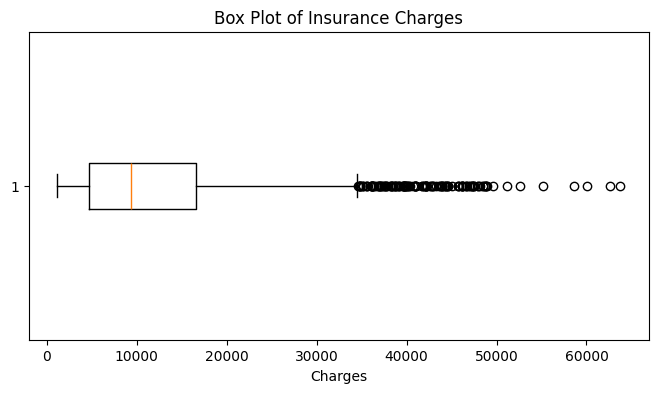

In [7]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_fill['charges'], vert=False)
plt.title('Box Plot of Insurance Charges')
plt.xlabel('Charges')
plt.show()


In [8]:
Q1 = df_fill['charges'].quantile(0.25)
Q3 = df_fill['charges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_fill[(df_fill['charges'] >= lower_bound) & (df_fill['charges'] <= upper_bound)].copy()

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower bound:', lower_bound)
print('Upper bound:', upper_bound)
print('Shape before outlier removal:', df_fill.shape)
print('Shape after outlier removal:', df_clean.shape)


Q1: 4740.28715
Q3: 16639.912515
IQR: 11899.625365
Lower bound: -13109.1508975
Upper bound: 34489.350562499996
Shape before outlier removal: (1338, 7)
Shape after outlier removal: (1199, 7)


## 6. Convert categorical variables using `get_dummies`

In [9]:
df_encoded = pd.get_dummies(df_clean, columns=['sex', 'smoker', 'region'], drop_first=True)

print('Encoded shape:', df_encoded.shape)
df_encoded.head()


Encoded shape: (1199, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## 7. Split features and target

In [10]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)


Feature matrix shape: (1199, 8)
Target shape: (1199,)


## 8. Train-test split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


X_train: (959, 8)
X_test : (240, 8)
y_train: (959,)
y_test : (240,)


## 9. Scale the data using Min-Max scaling


In [12]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaled training data shape:', X_train_scaled.shape)
print('Scaled testing data shape :', X_test_scaled.shape)


Scaled training data shape: (959, 8)
Scaled testing data shape : (240, 8)


## 10. Helper function for model evaluation

In [13]:
def evaluate_model(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    return {
        'Model': model_name,
        'Train MSE': mean_squared_error(y_train_true, y_train_pred),
        'Test MSE': mean_squared_error(y_test_true, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train_true, y_train_pred),
        'Test MAE': mean_absolute_error(y_test_true, y_test_pred),
        'Train R^2': r2_score(y_train_true, y_train_pred),
        'Test R^2': r2_score(y_test_true, y_test_pred),
    }


## 11. Linear Regression

In [14]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_train_pred = linear_model.predict(X_train_scaled)
linear_test_pred = linear_model.predict(X_test_scaled)

linear_results = evaluate_model(
    'Linear Regression',
    y_train, linear_train_pred,
    y_test, linear_test_pred
)

pd.DataFrame([linear_results])


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R^2,Test R^2
0,Linear Regression,1.904497e+07,2.764585e+07,4364.053812,5257.931786,2389.096751,2796.369561,0.616885,0.556818


## 12. Polynomial Regression



In [15]:
poly_results_list = []
best_poly_degree = None
best_poly_test_mse = float('inf')

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    train_pred = poly_model.predict(X_train_poly)
    test_pred = poly_model.predict(X_test_poly)

    result = evaluate_model(
        f'Polynomial Regression (degree={degree})',
        y_train, train_pred,
        y_test, test_pred
    )
    poly_results_list.append(result)

    if result['Test MSE'] < best_poly_test_mse:
        best_poly_test_mse = result['Test MSE']
        best_poly_degree = degree

poly_results_df = pd.DataFrame(poly_results_list)
poly_results_df


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R^2,Test R^2
0,Polynomial Regression (degree=2),1.653444e+07,2.668521e+07,4066.256148,5165.772684,2197.618987,2779.989826,0.667387,0.572217
1,Polynomial Regression (degree=3),1.488697e+07,2.858691e+07,3858.363152,5346.673059,2096.797941,2927.637138,0.700529,0.541732


In [16]:
print('Best polynomial degree:', best_poly_degree)


Best polynomial degree: 2


## 13. Random Forest Regression with tuning




In [17]:
rf_param_grid = {
    'n_estimators': [100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', None],
    'criterion': ['squared_error', 'absolute_error']
}

rf_base = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print('Best parameters:', rf_grid.best_params_)
print('Best CV score (negative MSE):', rf_grid.best_score_)


Best parameters: {'criterion': 'absolute_error', 'max_depth': 5, 'max_features': None, 'n_estimators': 100}
Best CV score (negative MSE): -17444242.344710693


In [18]:
best_rf = rf_grid.best_estimator_

rf_train_pred = best_rf.predict(X_train_scaled)
rf_test_pred = best_rf.predict(X_test_scaled)

rf_results = evaluate_model(
    'Random Forest Regression',
    y_train, rf_train_pred,
    y_test, rf_test_pred
)

pd.DataFrame([rf_results])


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R^2,Test R^2
0,Random Forest Regression,1.627225e+07,2.784435e+07,4033.88775,5276.774847,1475.991697,2138.542069,0.672662,0.553635


## 14. Final comparison of all models

In [19]:
best_poly_result = [row for row in poly_results_list if row['Model'] == f'Polynomial Regression (degree={best_poly_degree})'][0]

results_df = pd.DataFrame([
    linear_results,
    best_poly_result,
    rf_results
])

results_df = results_df.sort_values(by='Test MSE').reset_index(drop=True)
results_df


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R^2,Test R^2
0,Polynomial Regression (degree=2),1.653444e+07,2.668521e+07,4066.256148,5165.772684,2197.618987,2779.989826,0.667387,0.572217
1,Linear Regression,1.904497e+07,2.764585e+07,4364.053812,5257.931786,2389.096751,2796.369561,0.616885,0.556818
2,Random Forest Regression,1.627225e+07,2.784435e+07,4033.887750,5276.774847,1475.991697,2138.542069,0.672662,0.553635


## 15. Interpretation

In [20]:
best_model_name = results_df.loc[0, 'Model']
best_test_mse = results_df.loc[0, 'Test MSE']
best_test_r2 = results_df.loc[0, 'Test R^2']

print('Best model based on Test MSE:', best_model_name)
print('Best Test MSE:', best_test_mse)
print('Best Test R^2:', best_test_r2)


Best model based on Test MSE: Polynomial Regression (degree=2)
Best Test MSE: 26685207.42689283
Best Test R^2: 0.5722173596327413
